SCENARIO 1 – MULTINOMIAL NAÏVE BAYES

Import Required Libraries

In [52]:
print("Roll no - 24BAD008")
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.feature_extraction import text

Roll no - 24BAD008


Load Dataset

In [53]:
print("Roll no - 24BAD008")
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

Roll no - 24BAD008


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Data Preprocessing

In [54]:
print("Roll no - 24BAD008")
def clean_text(text_data):
    text_data = text_data.lower()
    text_data = re.sub(r'\d+', '', text_data)  
    text_data = text_data.translate(str.maketrans('', '', string.punctuation))  
    text_data = text_data.strip()
    return text_data

df['cleaned_message'] = df['message'].apply(clean_text)

Roll no - 24BAD008


Convert Text to Numerical Features

In [55]:
print("Roll no - 24BAD008")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['cleaned_message'])

Roll no - 24BAD008


Encode Target Labels

In [56]:
print("Roll no - 24BAD008")
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])   # ham = 0, spam = 1

Roll no - 24BAD008


Train-Test Split

In [57]:
print("Roll no - 24BAD008")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Roll no - 24BAD008


Train Multinomial Naïve Bayes

In [58]:
print("Roll no - 24BAD008")
model = MultinomialNB(alpha=1.0)  
model.fit(X_train, y_train)

Roll no - 24BAD008


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Predict

In [59]:
print("Roll no - 24BAD008")
y_pred = model.predict(X_test)

Roll no - 24BAD008


Evaluate Performance

In [60]:
print("Roll no - 24BAD008")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Roll no - 24BAD008
Accuracy: 0.9704035874439462
Precision: 0.8774193548387097
Recall: 0.9066666666666666
F1 Score: 0.8918032786885246


Confusion Matrix Visualization

Roll no - 24BAD008


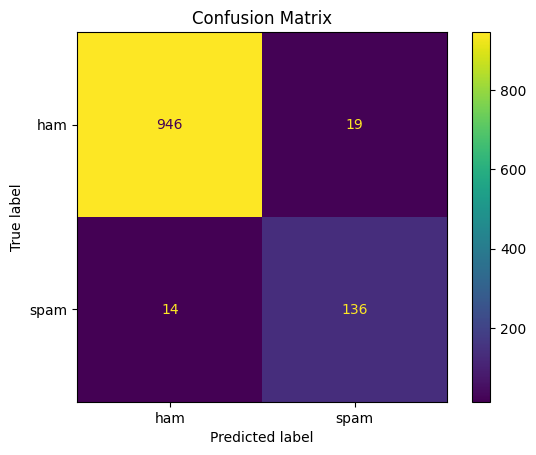

In [61]:
print("Roll no - 24BAD008")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Top Words Influencing Spam

Roll no - 24BAD008


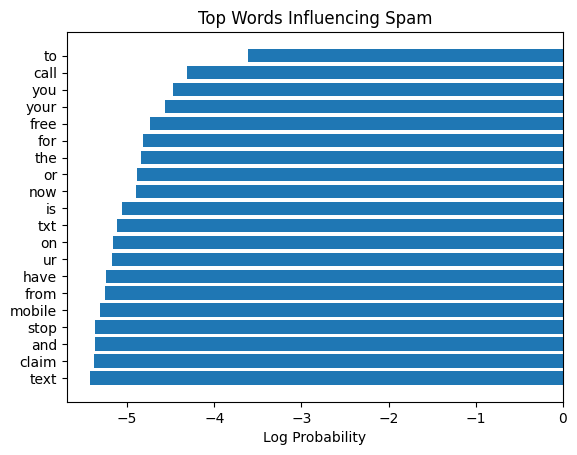

In [62]:
print("Roll no - 24BAD008")
feature_names = vectorizer.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]

top_indices = np.argsort(spam_probs)[-20:]

plt.figure()
plt.barh(feature_names[top_indices], spam_probs[top_indices])
plt.xlabel("Log Probability")
plt.title("Top Words Influencing Spam")
plt.show()

Word Frequency Comparison

In [63]:
print("Roll no - 24BAD008")
spam_df = df[df['label'] == 'spam']
ham_df = df[df['label'] == 'ham']

spam_vector = CountVectorizer().fit_transform(spam_df['cleaned_message'])
ham_vector = CountVectorizer().fit_transform(ham_df['cleaned_message'])

print("Top Spam Words:")
print(pd.Series(spam_vector.toarray().sum(axis=0)).sort_values(ascending=False).head())

print("\nTop Ham Words:")
print(pd.Series(ham_vector.toarray().sum(axis=0)).sort_values(ascending=False).head())

Roll no - 24BAD008
Top Spam Words:
1885    686
233     350
2222    287
2224    263
640     219
dtype: int64

Top Ham Words:
7256    1838
6462    1554
6332    1119
226      848
3033     813
dtype: int64


Misclassified Examples

In [64]:
print("Roll no - 24BAD008")
test_index = y_test.shape[0]

misclassified = []

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:
        misclassified.append(i)

print("Number of Misclassified Messages:", len(misclassified))

Roll no - 24BAD008
Number of Misclassified Messages: 33


Scenario - 2

Import Required Libraries

In [65]:
print("Roll no - 24BAD008")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

Roll no - 24BAD008


Load Iris Dataset

In [66]:
print("Roll no - 24BAD008")
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Features:", feature_names)
print("Classes:", target_names)

Roll no - 24BAD008
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


Data Inspection

In [67]:
print("Roll no - 24BAD008")
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

df.head()
df.describe()

Roll no - 24BAD008


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Apply Feature Scaling

In [68]:
print("Roll no - 24BAD008")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Roll no - 24BAD008


Train-Test Split

In [69]:
print("Roll no - 24BAD008")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Roll no - 24BAD008


Train Gaussian Naïve Bayes

In [70]:
print("Roll no - 24BAD008")
gnb = GaussianNB()
gnb.fit(X_train, y_train)

Roll no - 24BAD008


,priors,None
,var_smoothing,1e-09


Predict Species Labels

In [71]:
print("Roll no - 24BAD008")
y_pred = gnb.predict(X_test)

Roll no - 24BAD008


Evaluate Performance

In [72]:
print("Roll no - 24BAD008")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

Roll no - 24BAD008
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Compare Predictions with Actual Labels

In [73]:
print("Roll no - 24BAD008")
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

Roll no - 24BAD008


,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


Confusion Matrix

Roll no - 24BAD008


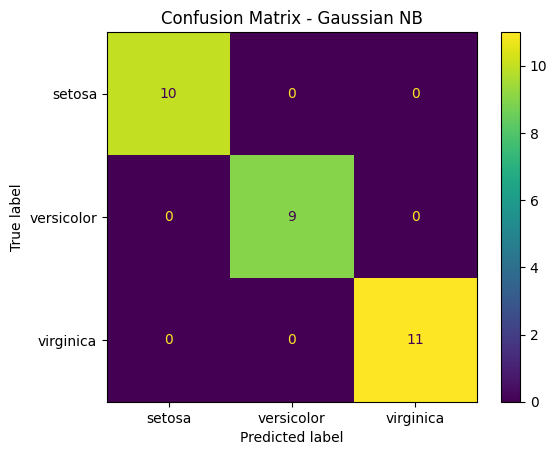

In [74]:
print("Roll no - 24BAD008")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

Analyze Class Probabilities

In [75]:
print("Roll no - 24BAD008")
probabilities = gnb.predict_proba(X_test)

print("Class Probabilities for first 5 samples:\n")
print(probabilities[:5])

Roll no - 24BAD008
Class Probabilities for first 5 samples:

[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]


Visualization 1: Decision Boundary

Roll no - 24BAD008


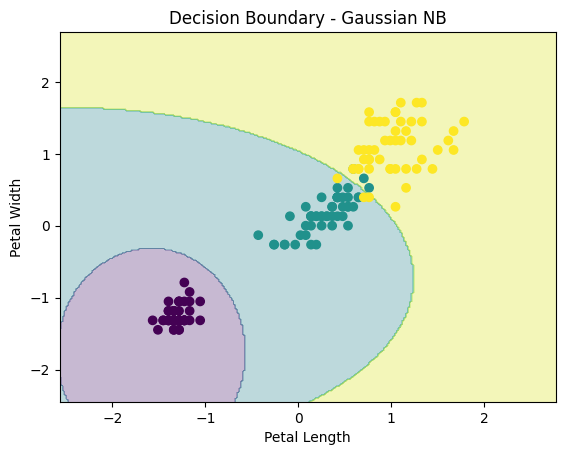

In [76]:
print("Roll no - 24BAD008")

X2 = X_scaled[:, 2:4]   # petal length & width
y2 = y

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

gnb2 = GaussianNB()
gnb2.fit(X_train2, y_train2)

# Create meshgrid
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y2)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

Probability Distribution Plot

Roll no - 24BAD008


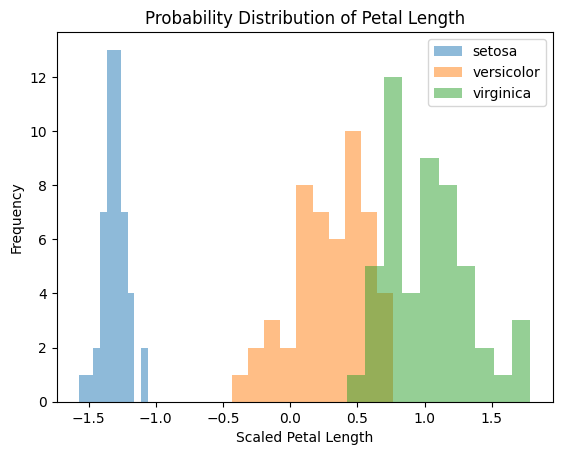

In [77]:
print("Roll no - 24BAD008")
plt.figure()

for i in range(3):
    plt.hist(X_scaled[y == i, 2], alpha=0.5, label=target_names[i])

plt.xlabel("Scaled Petal Length")
plt.ylabel("Frequency")
plt.legend()
plt.title("Probability Distribution of Petal Length")
plt.show()

Compare with Logistic Regression

In [78]:
print("Roll no - 24BAD008")
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Gaussian NB Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Roll no - 24BAD008
Gaussian NB Accuracy: 1.0
Logistic Regression Accuracy: 1.0
